<a href="https://colab.research.google.com/github/coder1317/AI-ML-IIIT/blob/main/Copy_of_AIML_Module_3_Lab_2_Implementing_KNN_from_scratch_and_visualize_Algorithm_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
### MODULE 3: CLASSIFICATION-1
### LAB-2 : Implementing KNN from scratch and visualize Algorithm performance

---

# **Section 1: Implementing KNN**

In the last lab we had started discussing about KNN or K Nearest Neighbour method for clasification. We used the pre-built scikit-learn library for KNN. Now let's see how to implement this algorithm from scratch  

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from collections import Counter

In [28]:
def predict(X_train, y_train, X_test, k):
    distances = []
    targets = []

    for i in range(len(X_train)):
        # compute and store L2 distance
        distances.append([np.sqrt(np.sum(np.square(X_test - X_train[i, :]))), i])

    distances = sorted(distances)

    for i in range(k):
        index = distances[i][1]
        targets.append(y_train[index])

    # return most common target
    return Counter(targets).most_common(1)[0][0]

In [29]:
def k_nearest_neighbor(X_train, y_train, X_test, k):

    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    # loop over all observations
    predictions = []
    for i in range(len(X_test)):
        predictions.append(predict(X_train, y_train, X_test[i, :], k))

    return np.asarray(predictions)

**Note** : If k = 1 then the algorithm will simply return the label of the nearest neighbour. When we give k > 1 the most common label out of the given labels in the k neighbours will be selected.The code for 1 NN is given as follows and does not have to be so complicated.

In [30]:
def NN1(traindata, trainlabel, query):
  diff  = traindata - query  # find the difference between features. Numpy automatically takes care of the size here
  sq = diff*diff # square the differences
  dist = sq.sum(1) # add up the squares
  label = trainlabel[np.argmin(dist)] # our predicted label is the label of the training data which has the least distance from the query
  return label

Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm.

In [31]:
def Accuracy(gtlabel, predlabel):
  assert len(gtlabel)==len(predlabel), "Length of the groundtruth labels and predicted labels should be the same"
  correct = (gtlabel==predlabel).sum() # count the number of times the groundtruth label is equal to the predicted label.
  return correct/len(gtlabel)

## Section 1.1 - Iris Dataset
Let's try it out on Iris Dataset present in the scikit learn library

In [32]:
from sklearn.datasets import load_iris

data = load_iris()

df = pd.DataFrame(data=data.data, columns=data.feature_names)

df["target"] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [33]:
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

In [34]:
# Making our predictions
predictions = k_nearest_neighbor(X_train, y_train, X_test, 7)

# evaluating accuracy
accuracy = Accuracy(y_test, predictions)
print("The accuracy of our classifier is {} %".format(100*accuracy))

The accuracy of our classifier is 94.0 %


Voila! You have implemented your own version of the K-Nearest Neighbours algorithm, which works very well on the Iris Dataset. Congratulations!  

Now try out the sklearn implementation and compare your results.  

In [35]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train,y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
accuracy = accuracy_score(y_test, sklearn_predictions)
print("The accuracy of Sklearn classifier is {} %".format(100*accuracy))

The accuracy of Sklearn classifier is 94.0 %


##  Section 1.2: Weighted NN
For KNN, If k is too small, the algorithm would be more sensitive to outliers. If k is too large, then the neighborhood may include too many points from other classes. We also take the label with max votes in the neighbourhood. Another choice can be that instead of giving equal weights to each of the neighbours we can give weighted points in the neighbourhood. So we weigh points by the inverse of their distance. Therefore, closer points will be given a higher priority as compared to the far off points.

An easy way to implement this is by specifying the 'weights' parameter as distance when defining the sklearn KNN function. For more information go through this [site](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [36]:
## TASK
## Modify the KNN function you wrote to return all the K-nearest neighbours along with their distances,
## instead of just the output that was most common. You don't need to find out accuracy, just modify the function
## and return the k-nearest neighbours and distances.
import numpy as np
from collections import Counter # Keep import for potential future use or context

# --- Added imports and data loading for independent execution ---
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_iris()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["target"] = data.target
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)
# -----------------------------------------------------------------

# Modified predict function to return k-nearest labels and their distances
def predict_modified(X_train, y_train, X_test_point, k):
    distances = []

    for i in range(len(X_train)):
        # Compute and store L2 distance (assuming Euclidean distance as in the original predict function)
        distances.append([np.sqrt(np.sum(np.square(X_test_point - X_train[i, :]))), i])

    # Sort distances to find the k-nearest
    distances.sort(key=lambda x: x[0]) # Sort by distance value

    k_nearest_labels = []
    k_nearest_distances = []

    # Get the k-nearest neighbors' labels and their distances
    for i in range(k):
        dist_val = distances[i][0]
        index_in_X_train = distances[i][1]
        k_nearest_distances.append(dist_val)
        k_nearest_labels.append(y_train[index_in_X_train])

    # Return the labels and distances of the k-nearest neighbors
    return k_nearest_labels, k_nearest_distances

# Modified k_nearest_neighbor function to use predict_modified
def k_nearest_neighbor_modified(X_train, y_train, X_test, k):
    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    all_k_nearest_data = []  # To store (labels, distances) for each test point

    for i in range(len(X_test)):
        # Call the modified predict function for each test point
        k_labels, k_distances = predict_modified(X_train, y_train, X_test[i, :], k)
        all_k_nearest_data.append({'test_point_index': i, 'k_nearest_labels': k_labels, 'k_nearest_distances': k_distances})

    return all_k_nearest_data

# --- Example Usage with Iris dataset data ---
# Assuming X_train, y_train, X_test are available from previous cells (Iris dataset preparation)
# Make sure to run the cells defining X_train, y_train, X_test first if running this in isolation

# You can use the `X_train`, `y_train`, `X_test` from the Iris dataset loaded earlier
# For example, using k=7 as in the earlier example:
k_value = 7

# Get the k-nearest neighbors and distances for all test points
all_predictions_and_distances = k_nearest_neighbor_modified(X_train, y_train, X_test, k_value)

print(f"Results for k={k_value}:")
# Print results for the first few test points to demonstrate
for i, result in enumerate(all_predictions_and_distances[:5]): # Print for first 5 test points
    print(f"\nTest Point Index: {result['test_point_index']}")
    print(f"  K-Nearest Labels: {result['k_nearest_labels']}")
    print(f"  K-Nearest Distances: {[f'{d:.2f}' for d in result['k_nearest_distances']]}")


Results for k=7:

Test Point Index: 0
  K-Nearest Labels: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
  K-Nearest Distances: ['0.35', '0.39', '0.41', '0.46', '0.46', '0.47', '0.48']

Test Point Index: 1
  K-Nearest Labels: [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1)]
  K-Nearest Distances: ['0.20', '0.24', '0.33', '0.44', '0.49', '0.50', '0.52']

Test Point Index: 2
  K-Nearest Labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
  K-Nearest Distances: ['0.24', '0.36', '0.36', '0.37', '0.42', '0.57', '0.57']

Test Point Index: 3
  K-Nearest Labels: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
  K-Nearest Distances: ['0.17', '0.22', '0.26', '0.36', '0.42', '0.52', '0.56']

Test Point Index: 4
  K-Nearest Labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1)

# **Section 2: Visualizing Data**  

We will look into something called **Voronoi** diagrams.  

**Note**: Ideally, we should perform data visualization to see what the data looks like before we apply any Machine Learning algorithm.  Only for the purpose of this lab session, we're explaining it after you've applied KNN.

### Voronoi Diagrams  

In simple terms, Voronoi diagrams help you to visualize the dataset by partioning the plane into regions that are close to a given set of points. These regions are also called Voronoi cells.  

Note that the cells/regions depend on the Distance metric being used. One way of interpreting this is by understanding that the distance metric decides the degree to which a 'point' or 'seed' in the Voronoi diagram has influence.  For each seed there is a corresponding region, called a Voronoi cell, consisting of all points of the plane closer to that seed than to any other.

This [link](https://en.wikipedia.org/wiki/Voronoi_diagram#Illustration) provides a wonderful illustration of Voronoi plots for 20 points in two cases: (1) Using Euclidean distance, and (2) Using Manhattan distance.  



Since our Iris data is 4-dimensional (as it has 4 attributes), we need to convert into a form that can be represented in 2-D.   

While there are methods to visualize data higher than 2-dimensions, that is beyond scope for now.  

For simplicity, we just take the first two columns of the iris dataset attributes and observe the Voronoi diagram generated for that.  
Alternatively, one can also perform PCA (Principal Component Analysis), to reduce the 4D data to just two dimensions.

In [37]:
#@title Plotting Voronoi regions
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.

    Parameters
    ----------
    vor : Voronoi
        Input diagram
    radius : float, optional
        Distance to 'points at infinity'.

    Returns
    -------
    regions : list of tuples
        Indices of vertices in each revised Voronoi regions.
    vertices : list of tuples
        Coordinates for revised Voronoi vertices. Same as coordinates
        of input vertices, with 'points at infinity' appended to the
        end.

    """

    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points, axis=0).max()

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge

            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

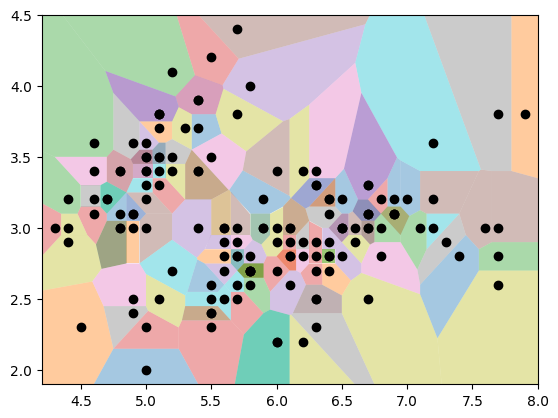

In [38]:
## Plotting Voronoi regions for the Iris dataset

points = []
xpts = np.array(df['sepal length (cm)'])
ypts = np.array(df['sepal width (cm)'])
for i in range(len(xpts)):
  points.append([xpts[i],ypts[i]])
# print(points)
points = np.array(points)
# compute Voronoi tesselation
vor = Voronoi(points)

regions,vertices = voronoi_finite_polygons_2d(vor)

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
plt.ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)

plt.show()

## Section 2.2: Understanding Decision Boundaries  
So you have seen the Voronoi diagram of the dataset, implemented KNN, and also seen your algorithm's performance in terms of accuracy? Impressive!  
Wouldn't it also be great to know how exactly these 'votes' or neighbours are decided through some kind of visualization?  


### Decision Boundary

While the Voronoi diagram gave us a good idea of the points present in our dataset, to understand how KNN performed on our dataset we can plot decision boundaries. Decision boundaries, as the name suggests, divide the plane into different regions of classification.  

Note that here again, for simplicity, we have only considered first two attributes of the DataFrame (ie, Sepal Length and Sepal Width).  

In [39]:
from matplotlib.colors import ListedColormap
import seaborn as sns


def decision_boundary_plot(x_dec,y_dec,k):
  h = .02  # step size in the mesh

  # Create color maps
  n = len(set(y_dec))
  cmap_light = ListedColormap(['pink', 'green', 'cyan','yellow'][:n])
  cmap_bold = ['pink', 'darkgreen', 'blue','yellow'][:n]

  for weights in ['uniform', 'distance']:
      # we create an instance of Neighbours Classifier and fit the data.
      clf = KNeighborsClassifier(n_neighbors=k, weights=weights)
      clf.fit(x_dec, y_dec)

      # Plot the decision boundary. For that, we will assign a color to each
      # point in the mesh [x_min, x_max]x[y_min, y_max].
      x_min, x_max = x_dec[:, 0].min() - 1, x_dec[:, 0].max() + 1
      y_min, y_max = x_dec[:, 1].min() - 1, x_dec[:, 1].max() + 1
      xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
      Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

      # Put the result into a color plot
      Z = Z.reshape(xx.shape)
      plt.figure(figsize=(8, 6))
      plt.contourf(xx, yy, Z, cmap=cmap_light)

      # Plot also the training points
      sns.scatterplot(x=x_dec[:, 0], y=x_dec[:, 1], hue=y_dec,
                      palette=cmap_bold, alpha=1.0, edgecolor="black")
      plt.xlim(xx.min(), xx.max())
      plt.ylim(yy.min(), yy.max())
      plt.title("Multi-Classification (k = %i, weights = '%s')"% (k, weights))

  plt.show()


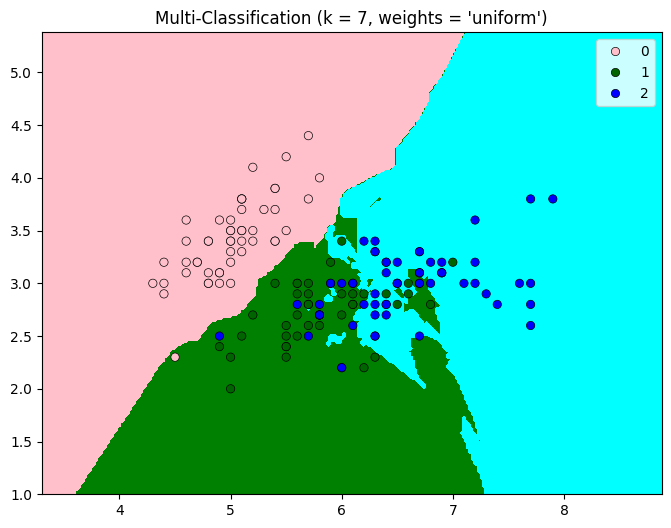

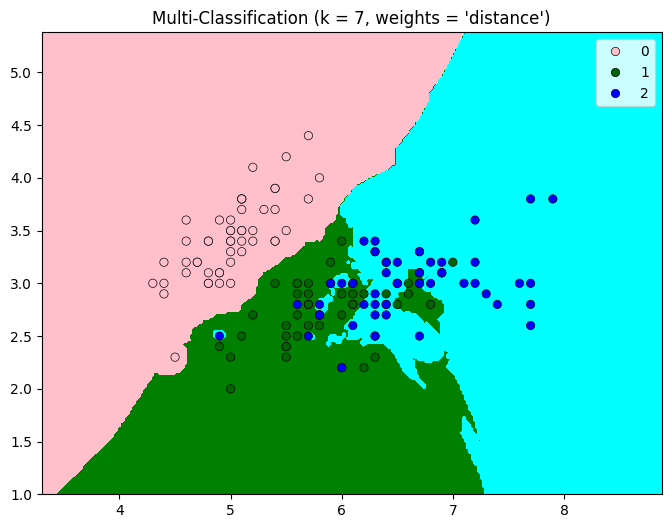

In [40]:
x_pts = X[:,:2]
y_pts = y
decision_boundary_plot(x_pts,y_pts,7)

Shape of data after PCA: (150, 2)

Plotting Voronoi Diagram for PCA-reduced data...


/tmp/ipykernel_899/176499150.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))


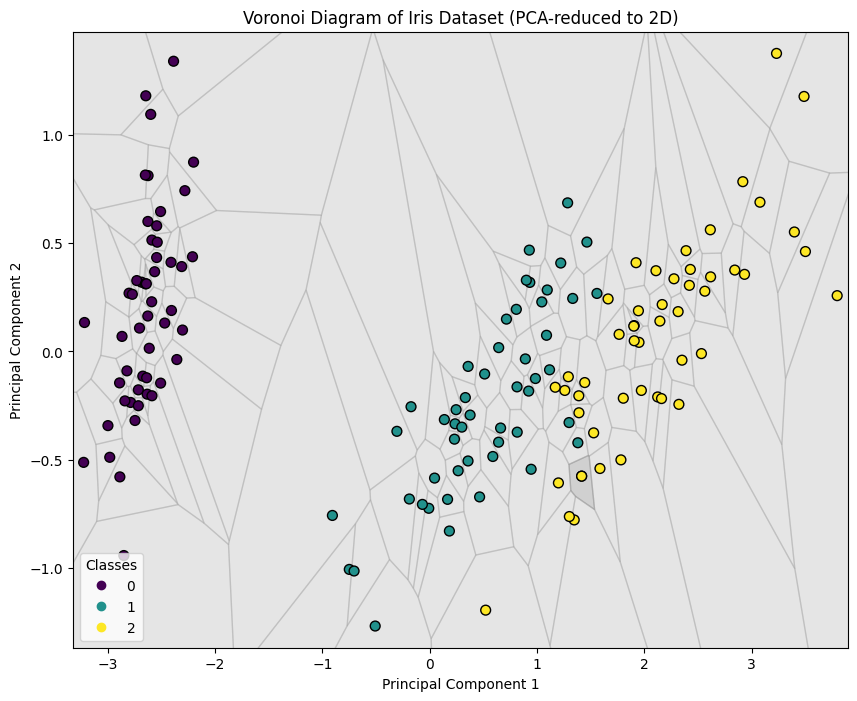


Plotting Decision Boundaries for PCA-reduced data...


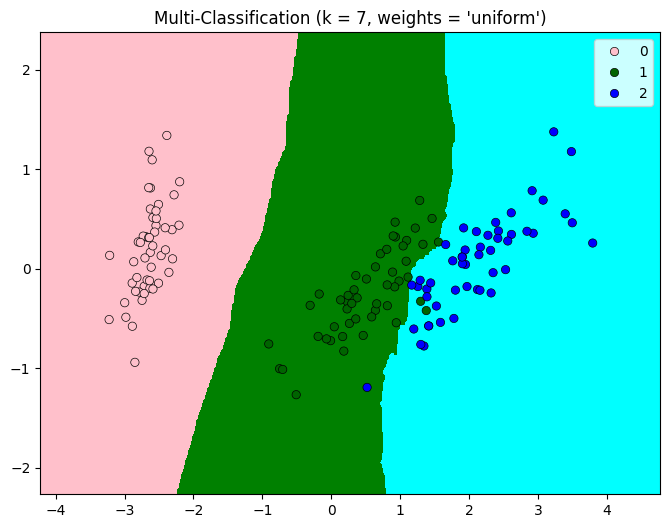

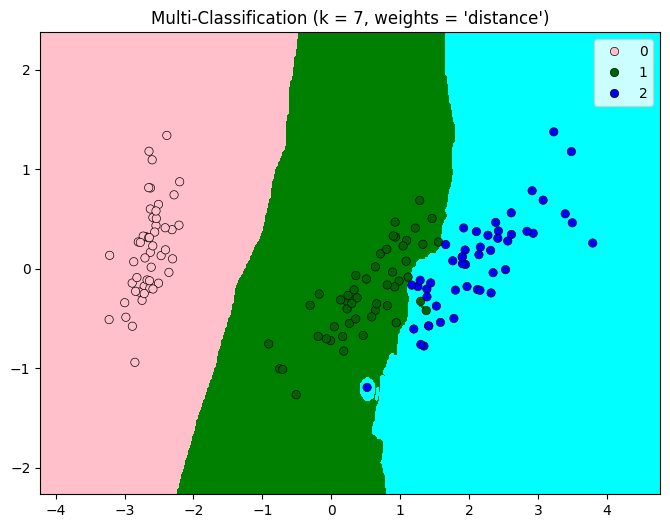

Task-2 complete. Voronoi and Decision Boundary plots generated for PCA-reduced data.


In [41]:
## TASK-2
## In the above cells, we saw the Voronoi diagram of the data and plotted the KNN decision boundaries
## by only considering two attributes of the dataset. You must be already familiar with PCA.
## Apply PCA on the dataset above to reduce it to two dimensions.
## Plot the Voronoi diagram and Decision boundaries after that.

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi # voronoi_plot_2d is not directly used in the plotting logic, just Voronoi

# 1. Apply PCA to reduce the dataset to two dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) # Use the global X and y from earlier cells
y_pca = y

print("Shape of data after PCA:", X_pca.shape)

# 2. Plot the Voronoi diagram after PCA
print("\nPlotting Voronoi Diagram for PCA-reduced data...")
# The voronoi_finite_polygons_2d function is already defined above.
# The plotting logic for Voronoi diagram is also similar to cell '9NIVhxz8KvG3'

plt.figure(figsize=(10, 8))
vor_pca = Voronoi(X_pca)
regions_pca, vertices_pca = voronoi_finite_polygons_2d(vor_pca)

# Get unique labels for coloring
unique_labels = np.unique(y_pca)
colors = plt.cm.get_cmap('viridis', len(unique_labels))

for i, region in enumerate(regions_pca):
    polygon = vertices_pca[region]
    # Color the regions based on the class of the original point
    # This is an approximation as Voronoi regions don't strictly correspond to classes.
    # A better approach would be to color based on classification of centroid or nearest point.
    # For simplicity, we'll try to color based on the point index corresponding to the region
    # Note: vor_pca.point_region[i] gives the region index, but coloring based on original y_pca directly is complex.
    # For this plot, we will just plot the points with their classes.
    plt.fill(*zip(*polygon), alpha=0.2, color='gray') # Fill regions neutrally

# Plot original points colored by their actual class (from y_pca)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pca, cmap=colors, edgecolors='k', s=50)

plt.title('Voronoi Diagram of Iris Dataset (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlim(vor_pca.min_bound[0] - 0.1, vor_pca.max_bound[0] + 0.1)
plt.ylim(vor_pca.min_bound[1] - 0.1, vor_pca.max_bound[1] + 0.1)
plt.show()


# 3. Plot the Decision boundaries after that.
print("\nPlotting Decision Boundaries for PCA-reduced data...")
# The decision_boundary_plot function is already defined above.
# Use a k-value, for example, 7 as used previously in the notebook.
decision_boundary_plot(X_pca, y_pca, k=7)

print("Task-2 complete. Voronoi and Decision Boundary plots generated for PCA-reduced data.")

## Section 2.3: Confusion Matrix  
In classification problems, a confusion matrix, also known as an error matrix, is a table that allows visualization of the performance of an algorithm, typically a supervised learning one. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
# print(confusion_matrix(y_test,predictions))
pd.crosstab(y_test, predictions, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,2,All
True,,,,
0,13,0,0,13
1,0,22,0,22
2,0,3,12,15
All,13,25,12,50


Text(0.5, 23.52222222222222, 'Predicted label')

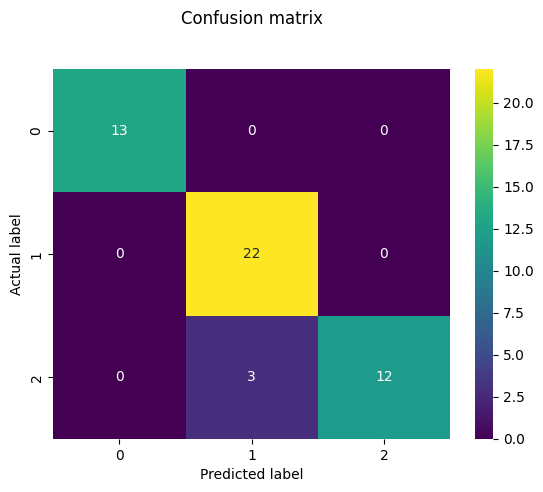

In [44]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, predictions)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="viridis" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

## Section 2.4: Classification Report

Precision, Recall, and F1-Score are other metrics besides accuracy that one might look for in an algorithm.  Depending on the use-case, one might consider one metric more important than the other.  

Note: *T-> True, F->False, P->Positive, N->Negative*
    
Mathematically, Accuracy is :  

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$  

**Precision**: The accuracy of positive predictions


$Precision = \frac{TP}{TP+FP}$

**Recall**:Fraction of positives that were correctly identified


$Recall = \frac{TP}{TP+FN}$


**F1-score**: Harmonic mean of precision and recall  


$F1 = \frac{2*Precision*Recall}{Precision+Recall} = \frac{2*TP}{2*TP+FP+FN}$  



In [45]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.88      1.00      0.94        22
           2       1.00      0.80      0.89        15

    accuracy                           0.94        50
   macro avg       0.96      0.93      0.94        50
weighted avg       0.95      0.94      0.94        50



### **Car Evaluation Dataset**

In [46]:
# Upload the Car evaluation data CSV file that has been shared with you.
# Run this cell, click on the 'Choose files' button and upload the file.
from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation (1).csv


In [47]:
car_df = pd.read_csv(list(uploaded.keys())[0])
car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [48]:
for x in car_df.columns:
  # print(x)
  le = preprocessing.LabelEncoder()
  le.fit(car_df[x])
  car_df[x]=le.transform(car_df[x])

car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,3,2,1,2,1
1723,1,1,3,2,1,0,3
1724,1,1,3,2,0,1,2
1725,1,1,3,2,0,2,1


In [49]:
dataset = car_df.values
X = dataset[:,0:6]
y = np.array(dataset[:,6])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [50]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
score = accuracy_score(y_test, predictions)
print("The accuracy of the classifier on Car evaluation dataset is {:.2f} %".format(100*score))

The accuracy of the classifier on Car evaluation dataset is 89.88 %


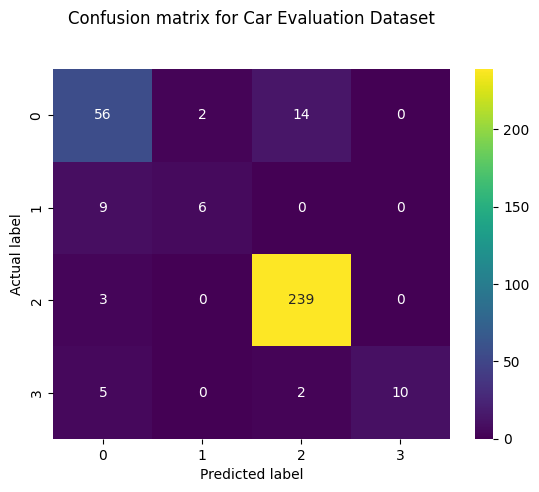

Confusion Matrix for Car Evaluation Dataset plotted successfully.


In [56]:
## TASK-3
## Plot a Confusion Matrix for the results of the Car evaluation dataset

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming y_test and predictions for the car evaluation dataset are available from previous cells.
# y_test and predictions were set in cell '1HL5ufCHDANh' for the car evaluation dataset.

cnf_matrix_car = confusion_matrix(y_test, predictions)
p = sns.heatmap(pd.DataFrame(cnf_matrix_car), annot=True, cmap="viridis" ,fmt='g')
plt.title('Confusion matrix for Car Evaluation Dataset', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

print("Confusion Matrix for Car Evaluation Dataset plotted successfully.")

In [57]:
## TASK-4
## Print a Classification Report for the results of the Car evaluation dataset

from sklearn.metrics import classification_report

# y_test and predictions for the car evaluation dataset are available from previous cells.
print("Classification Report for Car Evaluation Dataset:")
print(classification_report(y_test, predictions))

Classification Report for Car Evaluation Dataset:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77        72
           1       0.75      0.40      0.52        15
           2       0.94      0.99      0.96       242
           3       1.00      0.59      0.74        17

    accuracy                           0.90       346
   macro avg       0.86      0.69      0.75       346
weighted avg       0.90      0.90      0.89       346



Shape of Car Evaluation data after PCA: (1727, 2)

Plotting Decision Boundaries for PCA-reduced Car Evaluation data...


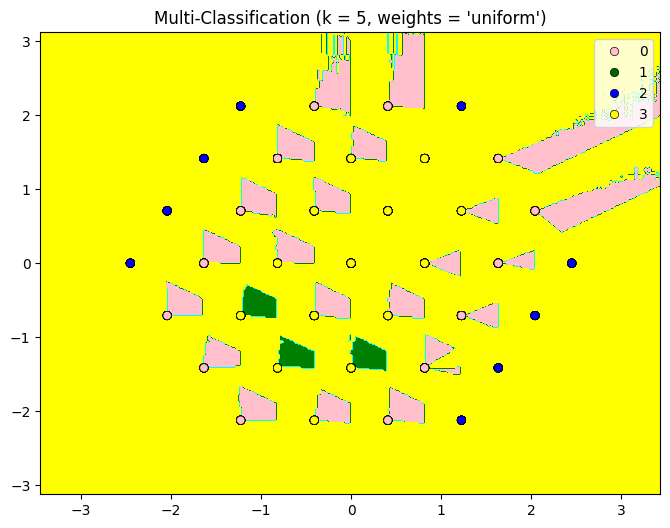

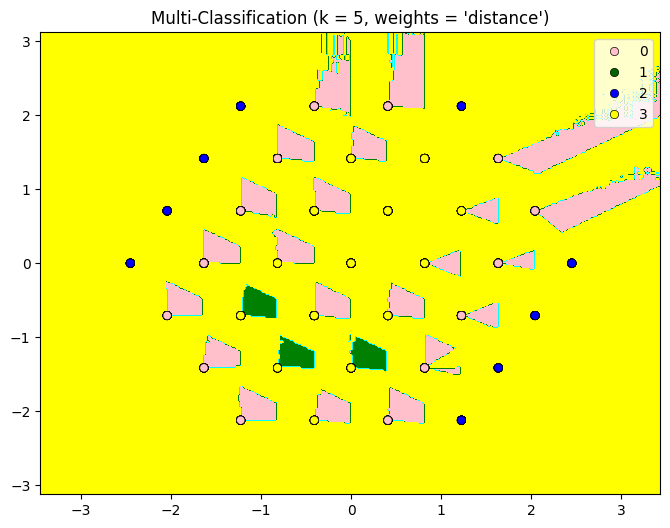

Task-5 complete. Decision Boundary plot generated for PCA-reduced Car Evaluation data.


In [58]:
## TASK-5
## Plot the Decision boundary diagram for the classifier of the Car evaluation dataset

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming X and y for the car evaluation dataset are available from previous cells.
# X = dataset[:,0:6]
# y = np.array(dataset[:,6])

# 1. Apply PCA to reduce the car evaluation dataset to two dimensions
pca_car = PCA(n_components=2)
X_car_pca = pca_car.fit_transform(X)
y_car_pca = y.astype(int) # Ensure y is integer type for plotting

print("Shape of Car Evaluation data after PCA:", X_car_pca.shape)

# 2. Plot the Decision boundaries after PCA
print("\nPlotting Decision Boundaries for PCA-reduced Car Evaluation data...")
# Use a k-value, for example, 5 as used previously for car evaluation dataset
k_value_car = 5
decision_boundary_plot(X_car_pca, y_car_pca, k=k_value_car)

print("Task-5 complete. Decision Boundary plot generated for PCA-reduced Car Evaluation data.")


Plotting Voronoi Diagram for PCA-reduced Car Evaluation data...
Original points: 1727, Unique points for Voronoi (X only): 424


/tmp/ipykernel_899/1870549157.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_car = plt.cm.get_cmap('viridis', len(unique_labels_car))


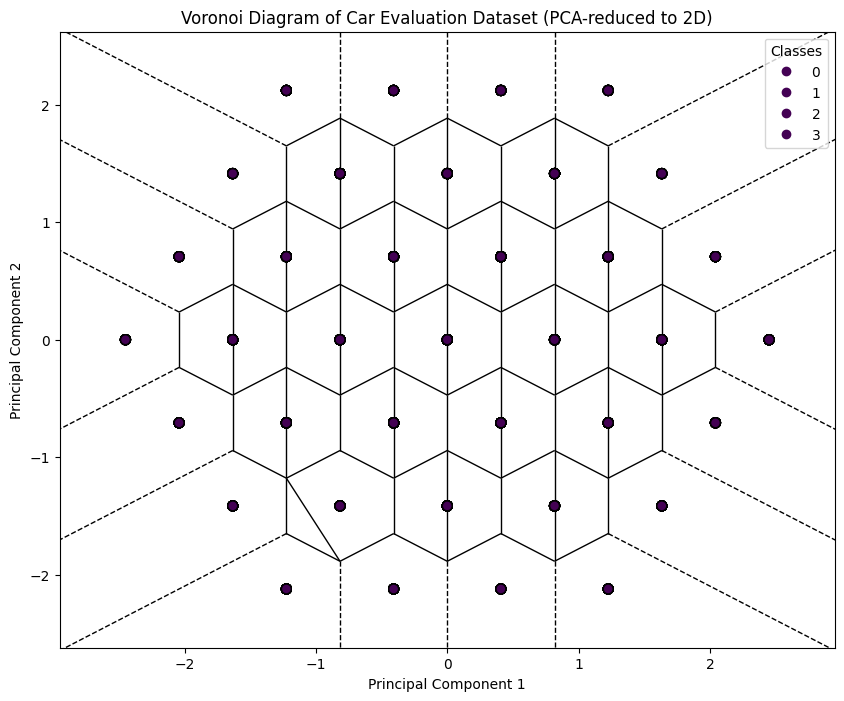

Task-6 complete. Voronoi Diagram generated for PCA-reduced Car Evaluation data.


In [61]:
## TASK-6
## Plot the Voronoi diagram for the classifier of the Car evaluation dataset

import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d # Added voronoi_plot_2d
import numpy as np

# X_car_pca and y_car_pca are available from the previous task (Task-5)
# They represent the car evaluation dataset reduced to 2 dimensions using PCA.

print("\nPlotting Voronoi Diagram for PCA-reduced Car Evaluation data...")

plt.figure(figsize=(10, 8))

# --- FIX: Ensure points are unique based only on X_car_pca coordinates ---
# Get unique points from X_car_pca coordinates
# We use return_index to get the index of the first occurrence of each unique row.
unique_coords, unique_indices_X = np.unique(X_car_pca, axis=0, return_index=True)

X_for_voronoi = unique_coords
# Corresponding labels for these unique points. This might be needed if we want to color Voronoi cells.
y_for_voronoi = y_car_pca[unique_indices_X] # Keep track of labels for unique points

print(f"Original points: {X_car_pca.shape[0]}, Unique points for Voronoi (X only): {X_for_voronoi.shape[0]}")

# Compute Voronoi diagram on unique points
vor_car_pca = Voronoi(X_for_voronoi)

# --- FIX: Replaced custom voronoi_finite_polygons_2d call with scipy's voronoi_plot_2d ---
# The voronoi_finite_polygons_2d function, while useful, is not robust to all degenerate cases
# produced by scipy.spatial.Voronoi, leading to KeyError. Using voronoi_plot_2d for robustness.
voronoi_plot_2d(vor_car_pca, show_points=False, show_vertices=False, ax=plt.gca())

# Get unique labels for coloring from the unique y_data (for coloring Voronoi cells later)
unique_labels_car = np.unique(y_for_voronoi)
colors_car = plt.cm.get_cmap('viridis', len(unique_labels_car))

# Plot original points (PCA-reduced) colored by their actual class (from y_car_pca)
# We still plot all original points here, as voronoi regions are for the space not just the unique points
scatter_car = plt.scatter(X_car_pca[:, 0], X_car_pca[:, 1], c=y_car_pca, cmap=colors_car, edgecolors='k', s=50, zorder=2) # zorder to ensure points are on top

plt.title('Voronoi Diagram of Car Evaluation Dataset (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter_car.legend_elements(), title="Classes")

# Adjust plot limits to fit all regions and points (using min/max bounds from Voronoi for sensible limits)
plt.xlim(vor_car_pca.min_bound[0] - 0.5, vor_car_pca.max_bound[0] + 0.5)
plt.ylim(vor_car_pca.min_bound[1] - 0.5, vor_car_pca.max_bound[1] + 0.5)

plt.show()

print("Task-6 complete. Voronoi Diagram generated for PCA-reduced Car Evaluation data.")

## **Homework Assignment: Exploring Distance Metrics and KNN**

---

### **Problem 1: Implementing Custom Distance Metrics**

In this exercise, you'll implement distance metrics from scratch to deepen your understanding.

**Task 1.1:** Implement the Minkowski distance formula without using any library functions (except basic numpy operations).

Recall that Minkowski distance is defined as:

$$d(x, x') = \left(\sum_{j=1}^{D} |x_j - x'_j|^p\right)^{1/p}$$

where $p$ is a parameter. When $p=1$, it's Manhattan distance, and when $p=2$, it's Euclidean distance.

In [62]:
## HOMEWORK TASK 1.1
## Implement the Minkowski distance function below
## Test it with p=1 (should match Manhattan) and p=2 (should match Euclidean)
## Expected number of lines: 3-5

from scipy.spatial import distance # Added import for testing

def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.

    Parameters:
    x1, x2: numpy arrays representing points
    p: the order of the Minkowski distance

    Returns:
    float: the Minkowski distance
    """
    # Write your code here
    return np.sum(np.abs(x1 - x2)**p)**(1/p)


# Test your implementation
x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()

# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance: 12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance: 7.0710678118654755


---

### **Problem 2: Visualizing Decision Boundaries**

Understanding how KNN makes predictions is crucial. In this exercise, you'll visualize decision boundaries for different values of K.

**Task 2.1:** Create a function that visualizes the decision boundary of a KNN classifier on 2D data.

**Hint:** You'll need to:
1. Create a mesh grid covering the feature space
2. Train a KNN classifier
3. Predict the class for each point in the mesh
4. Plot the results using `plt.contourf()` for the decision boundary
5. Overlay the training data points

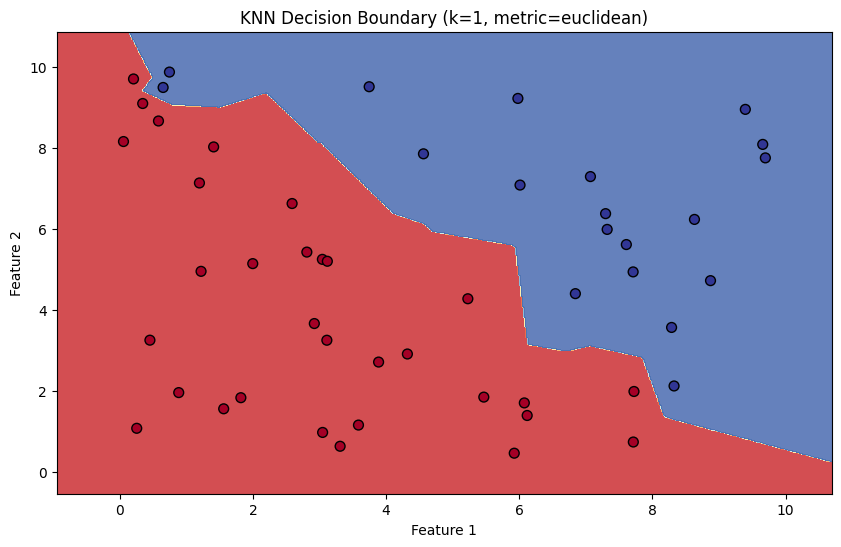

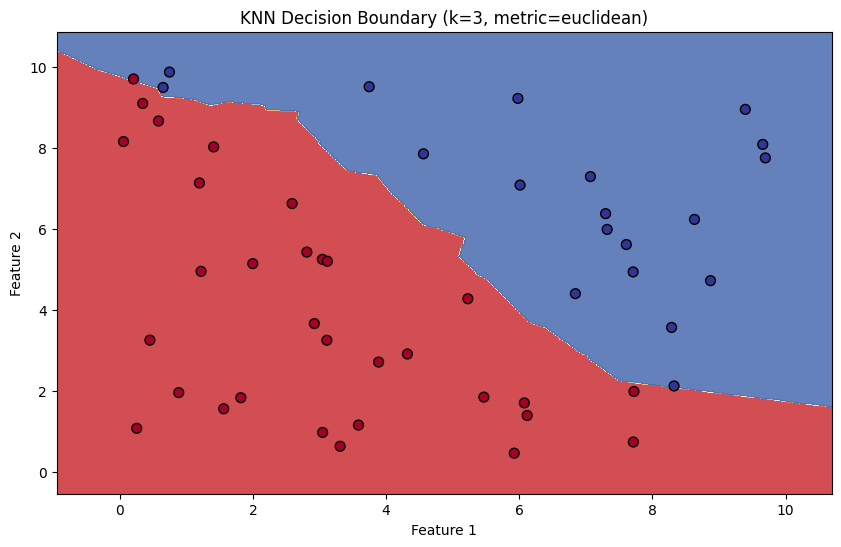

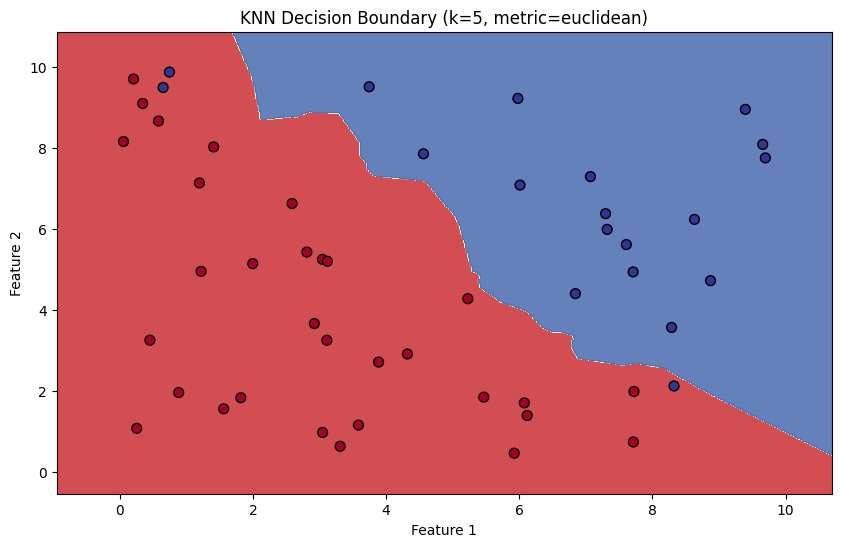

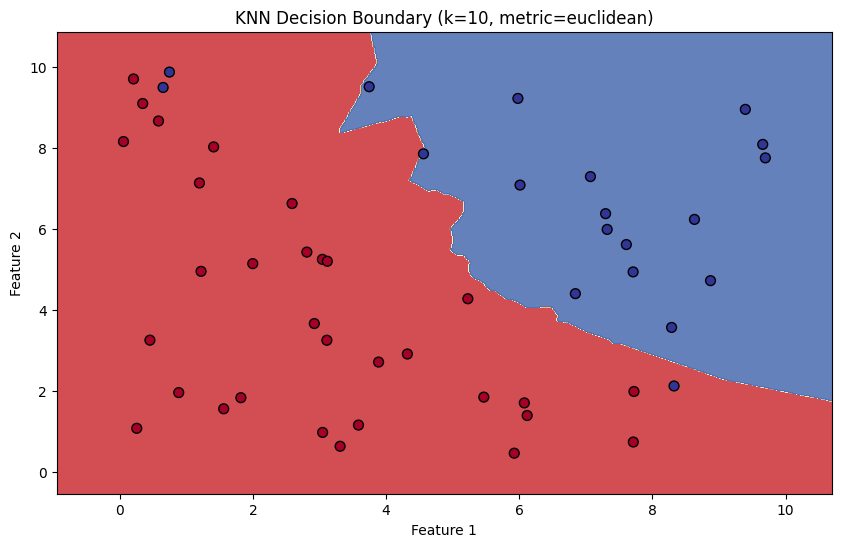

In [63]:
## HOMEWORK TASK 2.1
## Complete the function below to visualize KNN decision boundaries
## The function should create a mesh grid and predict class for each point

from sklearn.neighbors import KNeighborsClassifier # Added import
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.

    Parameters:
    X: Training data (n_samples, 2)
    y: Training labels
    k_value: Number of neighbors for KNN
    metric: Distance metric to use
    """
    # Create a mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Train KNN classifier
    # Write your code here to create and train KNN model
    knn_clf = KNeighborsClassifier(n_neighbors=k_value, metric=metric)
    knn_clf.fit(X, y)

    # Predict for each point in mesh
    # Write your code here to make predictions
    Z = knn_clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and training points
    plt.figure(figsize=(10, 6))
    # Write your code here to plot contours and scatter points
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=50)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')
    plt.show()

# Generate synthetic data (assuming generate_synth_data is defined elsewhere or will be provided)
# For now, I will define a placeholder for generate_synth_data for this cell to run.
# In a real scenario, this function should be implemented or imported if needed for the test.

def generate_synth_data(n):
    # Simple placeholder: generate random points and assign two classes based on a simple rule
    np.random.seed(42)
    X = np.random.rand(n, 2) * 10
    y = (X[:, 0] + X[:, 1] > 10).astype(int) # A simple boundary for illustration
    return X, y

# Test with different k values
n = 50 # Defined n here for the placeholder function
pts, tgts = generate_synth_data(n)

for k in [1, 3, 5, 10]:
    plot_decision_boundary(pts, tgts, k)

**Discussion Questions:**
1. What happens to the decision boundary as K increases? Is it smoother or more irregular?
2. Which K value seems to generalize better without overfitting?
3. Try changing the metric to 'manhattan' - how does the boundary change?

---

### **Problem 3: Impact of Distance Metrics on High-Dimensional Data**

The "curse of dimensionality" affects distance metrics differently. Let's explore this phenomenon.

**Task 3.1:** Create a function that generates random high-dimensional data and compares how different distance metrics behave as dimensionality increases.

**Background:** In high dimensions, the ratio between the maximum and minimum distances between points tends to approach 1, making it harder to distinguish between near and far neighbors. This affects different metrics differently.

Analyzing distance metrics in increasing dimensionality...
  Testing dimension: 2
  Testing dimension: 7
  Testing dimension: 12
  Testing dimension: 17
  Testing dimension: 22
  Testing dimension: 27
  Testing dimension: 32
  Testing dimension: 37
  Testing dimension: 42
  Testing dimension: 47


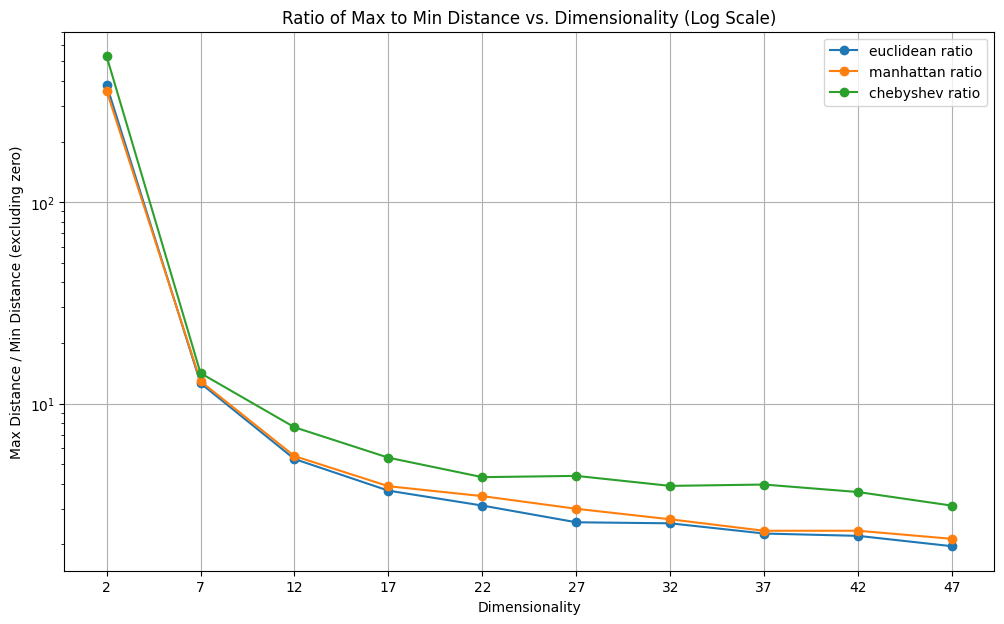


Analysis complete. Plot generated.


In [64]:
## HOMEWORK TASK 3.1
## Complete the function to analyze distance metrics in high dimensions
## Calculate the ratio of max distance to min distance for each metric

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform # Import pdist for efficient pairwise distance calculation

def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    """
    Analyze how distance metrics behave in high dimensions.

    Parameters:
    max_dim: Maximum dimensionality to test
    n_points: Number of random points to generate

    Returns:
    Dictionary with results for each metric
    """
    # Ensure 2 is always included in dimensions if not covered by range step
    dimensions = list(range(2, max_dim + 1, 5))
    if 2 not in dimensions:
        dimensions.insert(0, 2)

    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    print("Analyzing distance metrics in increasing dimensionality...")

    for dim in dimensions:
        print(f"  Testing dimension: {dim}")
        # Generate random points
        # Using a fixed seed for reproducibility across dimensions for consistency
        np.random.seed(42)
        points = np.random.randn(n_points, dim)

        # Calculate all pairwise distances for each metric
        # Euclidean
        euclidean_dists = pdist(points, metric='euclidean')
        # Filter out zero distances (distance of a point to itself)
        min_euclidean = np.min(euclidean_dists[euclidean_dists > 1e-9]) # Use a small epsilon to avoid floating point issues with 0
        max_euclidean = np.max(euclidean_dists)
        results['euclidean'].append(max_euclidean / min_euclidean)

        # Manhattan (cityblock)
        manhattan_dists = pdist(points, metric='cityblock')
        min_manhattan = np.min(manhattan_dists[manhattan_dists > 1e-9])
        max_manhattan = np.max(manhattan_dists)
        results['manhattan'].append(max_manhattan / min_manhattan)

        # Chebyshev
        chebyshev_dists = pdist(points, metric='chebyshev')
        min_chebyshev = np.min(chebyshev_dists[chebyshev_dists > 1e-9])
        max_chebyshev = np.max(chebyshev_dists)
        results['chebyshev'].append(max_chebyshev / min_chebyshev)

    # Plot results
    plt.figure(figsize=(12, 7))
    for metric, ratios in results.items():
        plt.plot(dimensions, ratios, marker='o', label=f'{metric} ratio')

    plt.title('Ratio of Max to Min Distance vs. Dimensionality (Log Scale)')
    plt.xlabel('Dimensionality')
    plt.ylabel('Max Distance / Min Distance (excluding zero)')
    plt.grid(True)
    plt.legend()
    plt.yscale('log') # Use log scale because ratios can grow very large
    plt.xticks(list(dimensions)) # Ensure all tested dimensions are shown on x-axis
    plt.show()

    print("\nAnalysis complete. Plot generated.")
    return results

# Run the analysis
results = analyze_distance_in_high_dims(max_dim=50, n_points=100)


### Questions to Think About and Answer
1. In the section on Decision boundaries, you must have seen that we ran the KNN algorithm twice: first with the _weights_ set to 'uniform' and then set to 'distance'. Find out the difference between these two.  
2. What do you think could be the drawbacks of using KNN ?

**1. Difference between 'uniform' and 'distance' weights in KNN:**

When weights is set to 'uniform' (the default), all k nearest neighbors have an equal vote in the classification of a new data point. This means that if a new point has 3 neighbors from class A and 2 from class B, it will be classified as class A, regardless of how close or far those neighbors are.

When weights is set to 'distance', the vote of each neighbor is weighted by the inverse of its distance to the new data point. Closer neighbors have a greater influence on the classification than farther neighbors. So, if a neighbor from class B is very close, and three neighbors from class A are slightly further away, the closer class B neighbor might 'outweigh' the three class A neighbors, leading to a classification of class B.

In essence, 'distance' weighting gives more importance to the immediate vicinity of the query point, potentially leading to more localized and sometimes more accurate decision boundaries, especially when classes are not perfectly separable.


**2. Drawbacks of using KNN:**

KNN, despite its simplicity and effectiveness, has several drawbacks:

**Computational Cost:** For prediction, KNN needs to calculate the distance from the new data point to all existing training data points. This can be very slow, especially with large datasets, making it computationally expensive for real-time applications.

**Memory Usage:** KNN is a non-parametric, instance-based learning algorithm, meaning it stores the entire training dataset. This requires significant memory, which can be an issue for very large datasets.

**Curse of Dimensionality:** In high-dimensional spaces, the concept of 'nearest neighbor' becomes less meaningful. Distances between points tend to become very similar (as demonstrated in Homework Task 3.1), making it difficult to distinguish between the closest and furthest neighbors. This can severely degrade KNN's performance.

**Sensitivity to Irrelevant Features:** If the dataset contains many irrelevant features, these features can disproportionately influence the distance calculation, leading to poor performance. Feature scaling and selection are crucial.
Imbalanced Data: If one class is significantly more represented than others in the training data, KNN tends to be biased towards the majority class. A new data point might be close to many majority class examples, even if its true class is the minority.

**Choosing the Optimal 'k':** The performance of KNN heavily depends on the choice of k. A small k can make the model sensitive to noise and outliers (overfitting), while a large k can smooth out the decision boundaries too much, potentially ignoring local patterns (underfitting). Finding the best k often requires cross-validation.

**No Explicit Model:** Since KNN is a lazy learning algorithm, it doesn't learn an explicit model during training. This can make it harder to interpret why a particular prediction was made, compared to models like decision trees or linear regression.

### Useful Resources for further reading
1. Interactive KNN visualization, with class boundaries: http://vision.stanford.edu/teaching/cs231n-demos/knn/  
